In [1]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Data Collection (yfinance)
import yfinance as yf
import pandas as pd

# Choose stock
stock = "AAPL"

# Download data
data = yf.download(stock, start="2015-01-01", end="2024-01-01")

# Save to CSV (file will be created)
file_path = "stock_data.csv"
data.to_csv(file_path)

# Read from CSV
df = pd.read_csv(file_path)

# View data
print(df.head())

[*********************100%***********************]  1 of 1 completed

        Price               Close                High                 Low  \
0      Ticker                AAPL                AAPL                AAPL   
1        Date                 NaN                 NaN                 NaN   
2  2015-01-02   24.17176055908203  24.638260409797738  23.734001789774272   
3  2015-01-05   23.49079704284668   24.02141303105321  23.305082374704345   
4  2015-01-06  23.493011474609375  23.751686233274114  23.132633885246175   

                 Open     Volume  
0                AAPL       AAPL  
1                 NaN        NaN  
2  24.627205239450436  212818400  
3  23.941820548483143  257142000  
4   23.55491637205578  263188400  


In [7]:
# Data Preprocessing
import pandas as pd

# 1. Skip the extra header rows and parse the Date column
data = pd.read_csv("stock_data.csv", header=2, index_col="Date", parse_dates=True)

# 2. Ensure numeric types for all price columns
data = data.apply(pd.to_numeric, errors="coerce")

# 3. Handle missing values
data = data.dropna()

# 4. Feature Engineering
if "Close" in data.columns:
    data["MA_10"] = data["Close"].rolling(window=10).mean()
    data["MA_50"] = data["Close"].rolling(window=50).mean()

    # Create target (next day's closing price)
    data["Target"] = data["Close"].shift(-1)

# Drop NaN values introduced by rolling windows and shifting
data = data.dropna()

print(data.head())

            Unnamed: 1  Unnamed: 2  Unnamed: 3  Unnamed: 4  Unnamed: 5
Date                                                                  
2015-01-02   24.214893   24.682226   23.776353   24.671151   212818400
2015-01-05   23.532722   24.064285   23.346676   23.984551   257142000
2015-01-06   23.534937   23.794073   23.173916   23.596952   263188400
2015-01-07   23.864946   23.964614   23.632387   23.743129   160423600
2015-01-08   24.781895   24.839481   24.075359   24.192747   237458000


In [8]:
import matplotlib.pyplot as plt

# Clean column names
data.columns = data.columns.str.strip()

print("Columns in dataset:", data.columns)

# Use correct names (adjust if needed after print)
if "Age" in data.columns and "Spending Score (1-100)" in data.columns:
    
    plt.figure(figsize=(10,5))
    plt.scatter(data["Age"], data["Spending Score (1-100)"])
    
    plt.title("Age vs Spending Score")
    plt.xlabel("Age")
    plt.ylabel("Spending Score")
    
    plt.show()

else:
    print("Column names not found. Check your dataset columns carefully.")

Columns in dataset: Index(['Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5'], dtype='object')
Column names not found. Check your dataset columns carefully.


In [10]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 🔹 1. Load data (update this path to where your file actually is)
file_path = "stock_data.csv"  # or r"C:\path\to\your\stock_data.csv"

try:
    # If the file has standard single header
    data = pd.read_csv(file_path)
except FileNotFoundError:
    raise FileNotFoundError(
        f"File not found at {file_path}. Please verify the file location."
    )

# 🔹 2. Clean column names
data.columns = data.columns.str.strip().str.lower()
print("Columns in dataset:", list(data.columns))

# 🔹 3. Convert date column (if exists)
if "date" in data.columns:
    data["date"] = pd.to_datetime(data["date"], errors="coerce")
    data = data.sort_values("date")

# 🔹 4. Ensure price/volume columns are numeric
numeric_cols = ["open", "high", "low", "close", "volume"]
for col in numeric_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")

# 🔹 5. Drop missing values
data = data.dropna()

# 🔹 6. Select features & train model
required_cols = ["open", "high", "low", "close", "volume"]
missing_cols = [col for col in required_cols if col not in data.columns]

if missing_cols:
    print("❌ Missing columns:", missing_cols)
    print("👉 Available columns:", list(data.columns))
else:
    X = data[["open", "high", "low", "volume"]]
    y = data["close"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    print("\n✅ Model trained successfully!")

    # Evaluation
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    print("\n📊 Model Performance:")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2 Score: {r2:.4f}")
    print(f"Accuracy (R2 %): {r2 * 100:.2f}%")

Columns in dataset: ['price', 'close', 'high', 'low', 'open', 'volume']

✅ Model trained successfully!

📊 Model Performance:
MSE: 0.6693
RMSE: 0.8181
MAE: 0.5084
R2 Score: 0.9998
Accuracy (R2 %): 99.98%


Columns: ['price', 'close', 'high', 'low', 'open', 'volume']
Using features: ['open', 'high', 'low', 'volume']
Target: close

✅ Model trained successfully!

📊 Model Performance:
MSE: 0.6693
RMSE: 0.8181
MAE: 0.5084
R2 Score: 0.9998
Accuracy (R2 %): 99.98%


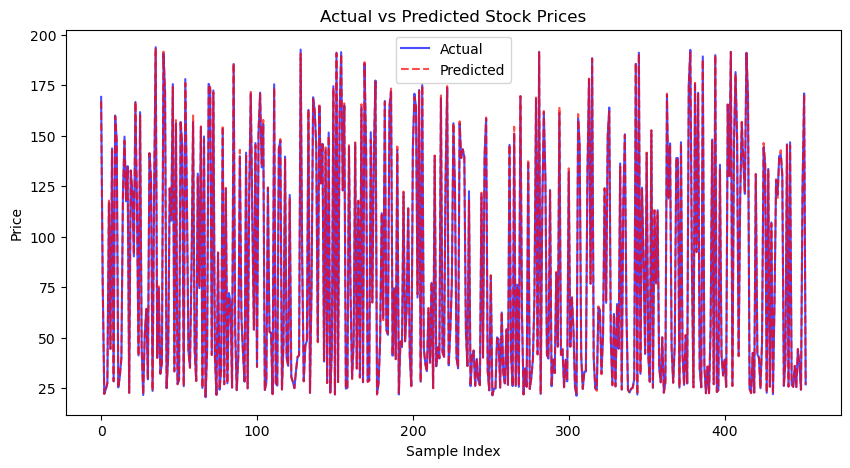

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# =========================
# 1. LOAD DATA
# =========================
# Load using relative path (same directory as the notebook)
data = pd.read_csv("stock_data.csv")

# =========================
# 2. CLEAN COLUMN NAMES
# =========================
data.columns = data.columns.str.strip().str.lower()
print("Columns:", list(data.columns))

# =========================
# 3. CONVERT NUMERIC COLUMNS & CLEAN
# =========================
price_cols = ["open", "high", "low", "close", "volume"]
for col in price_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")

# Drop any rows with NaN values after conversion
data = data.dropna()

# =========================
# 4. FEATURES & TARGET
# =========================
# Features: open, high, low, volume | Target: close
feature_cols = [
    col for col in ["open", "high", "low", "volume"] if col in data.columns
]
X = data[feature_cols]
y = data["close"]

print("Using features:", list(X.columns))
print("Target:", y.name)

# =========================
# 5. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 6. MODEL TRAINING
# =========================
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("\n✅ Model trained successfully!")

# =========================
# 7. PREDICTIONS & EVALUATION
# =========================
predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("\n📊 Model Performance:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2 Score: {r2:.4f}")
print(f"Accuracy (R2 %): {r2 * 100:.2f}%")

# =========================
# 8. GRAPH
# =========================
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label="Actual", color="blue", alpha=0.7)
plt.plot(
    predictions, label="Predicted", color="red", linestyle="--", alpha=0.7
)
plt.legend()
plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Sample Index")
plt.ylabel("Price")
plt.show()

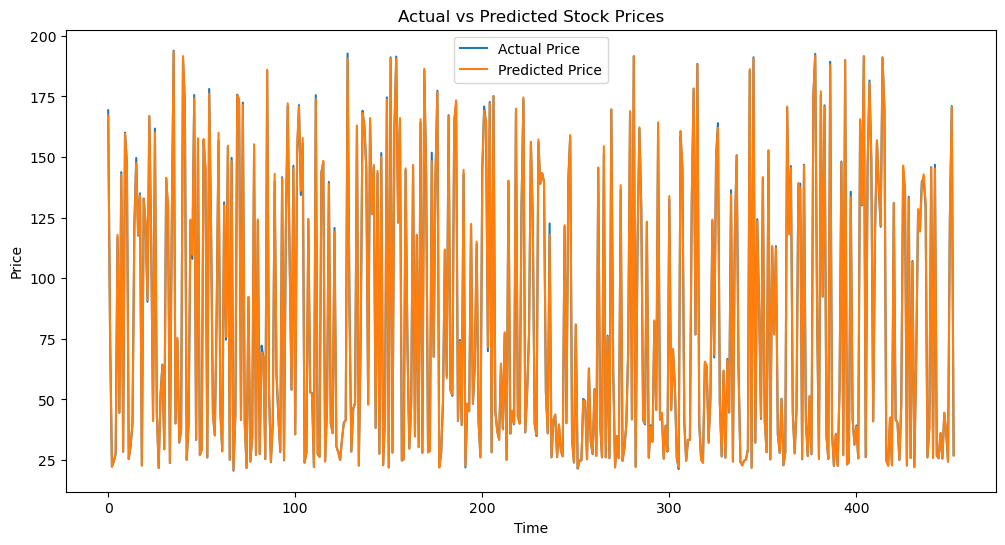

In [13]:
# Plot Predicted vs Actual

plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual Price")
plt.plot(predictions, label="Predicted Price")

plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()

plt.show()

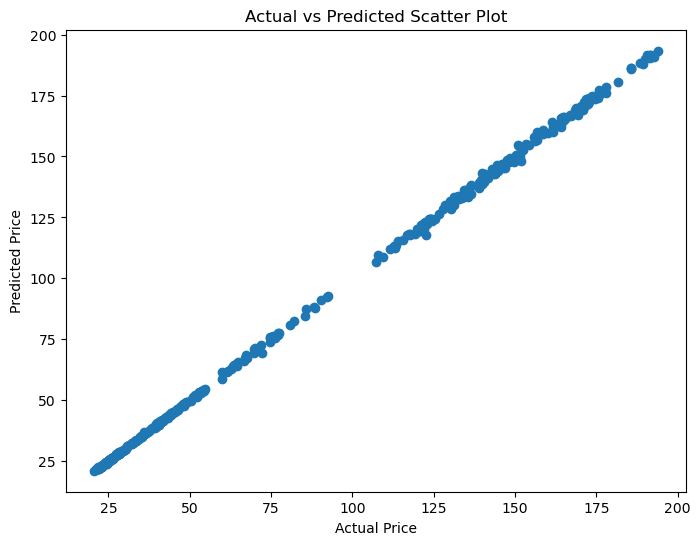

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Scatter Plot")

plt.show()

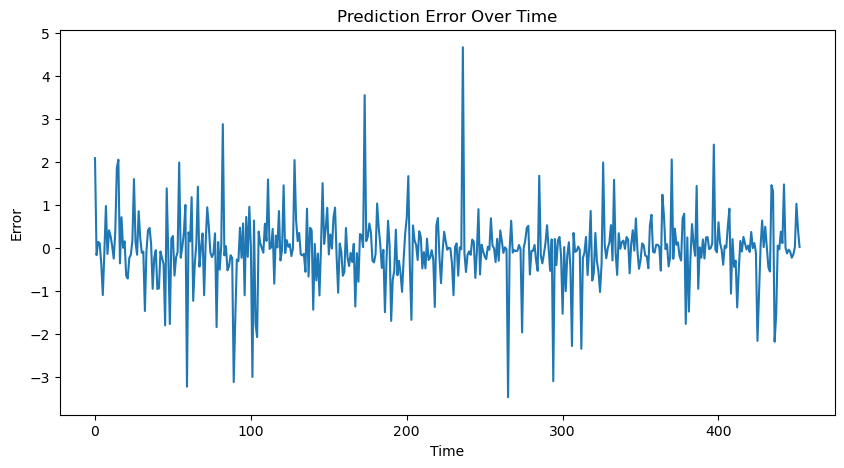

In [15]:
errors = y_test.values - predictions

plt.figure(figsize=(10,5))

plt.plot(errors)

plt.title("Prediction Error Over Time")
plt.xlabel("Time")
plt.ylabel("Error")

plt.show()

In [16]:
# Optional: Predict Next Day Price

# Take last available row
latest_data = X.tail(1)

next_day_prediction = model.predict(latest_data)

print("Predicted Next Day Price:", next_day_prediction[0])

Predicted Next Day Price: 190.5427001953125
